In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adeniranstephen/obesity-prediction-dataset/ObesityDataSet_raw_and_data_sinthetic.csv


# EDA

In [56]:
df = pd.read_csv('/kaggle/input/datasets/adeniranstephen/obesity-prediction-dataset/ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [58]:
df.shape

(2111, 17)

In [59]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.418986,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.533996,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.390000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [60]:
df.isna().sum().sum()

np.int64(0)

In [61]:
# check targe dist
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

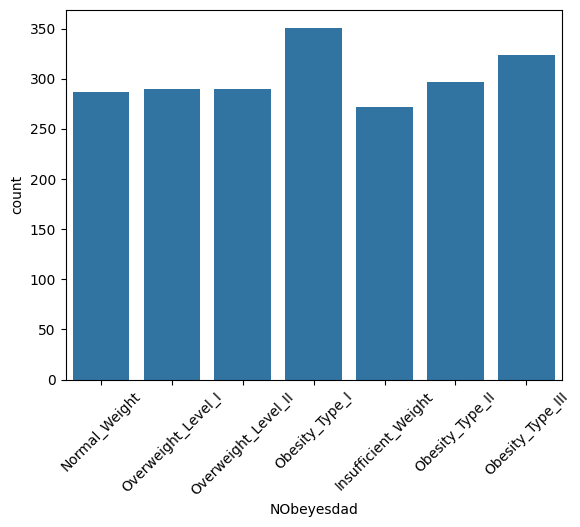

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.show()

In [63]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print('NUMERICAL Cols is :',num_cols)
print('\nCATEGORICAL Cols is :',cat_cols)

NUMERICAL Cols is : Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')

CATEGORICAL Cols is : Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


In [64]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [65]:
#recheck all 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   int64  
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   int64  
 5   FAVC                            2111 non-null   int64  
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   int64  
 9   SMOKE                           2111 non-null   int64  
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   int64  
 12  FAF                             21

In [66]:
# split
X = df.drop("NObeyesdad", axis=1)
y = df['NObeyesdad']

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

# Logistic Reg 

In [68]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [70]:
y_pred_log = log_model.predict(X_test)

In [71]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8723404255319149


In [72]:
print(confusion_matrix(y_test, y_pred_log))

[[53  1  0  0  0  0  0]
 [ 6 41  0  0  0 10  1]
 [ 0  0 65  2  0  1  2]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  5  1  0  0 45  7]
 [ 0  2  7  0  0  7 42]]


In [73]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        54
           1       0.84      0.71      0.77        58
           2       0.88      0.93      0.90        70
           3       0.95      0.98      0.97        60
           4       1.00      0.98      0.99        65
           5       0.71      0.78      0.74        58
           6       0.81      0.72      0.76        58

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.87      0.87      0.87       423



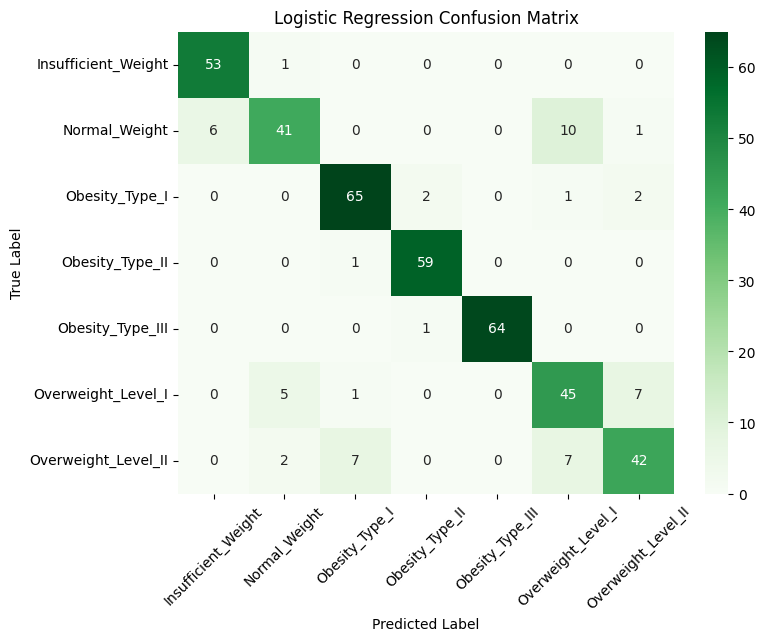

In [74]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Decision Tree

In [75]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, random_state=42)

In [76]:
y_pred_tree = tree_model.predict(X_test)

In [77]:
print("Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Tree Accuracy: 0.900709219858156


In [78]:
print(confusion_matrix(y_test, y_pred_tree))

[[47  7  0  0  0  0  0]
 [ 1 46  0  0  0 11  0]
 [ 0  1 66  1  0  1  1]
 [ 0  0  2 58  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  7  0  0  0 51  0]
 [ 0  0  3  0  0  6 49]]


In [79]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92        54
           1       0.75      0.79      0.77        58
           2       0.93      0.94      0.94        70
           3       0.97      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.74      0.88      0.80        58
           6       0.98      0.84      0.91        58

    accuracy                           0.90       423
   macro avg       0.91      0.90      0.90       423
weighted avg       0.91      0.90      0.90       423



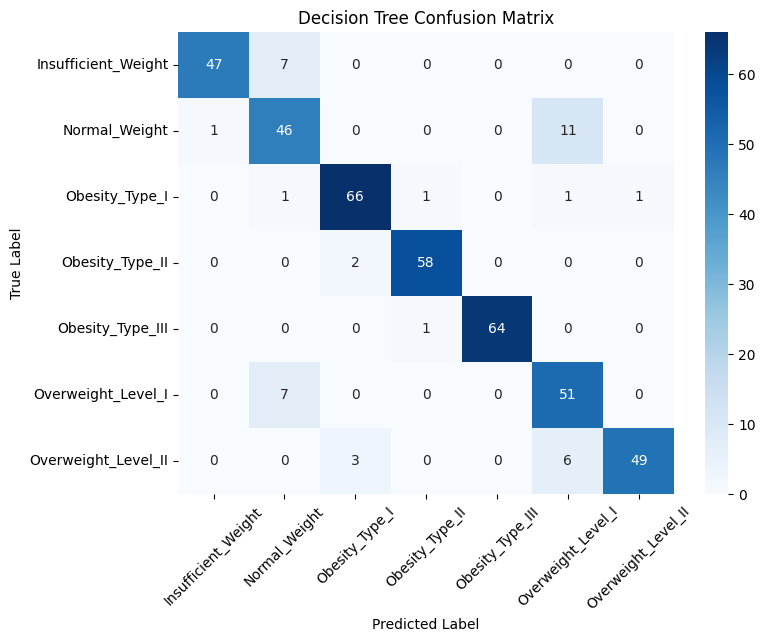

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()